In [ ]:
import zipfile

with zipfile.ZipFile(r'/content/speechocean.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

In [ ]:
!find /content -type d | grep learners

/content/speechocean/train/learners
/content/speechocean/test/learners


In [ ]:
folder= "/content/speechocean/train/learners"

In [ ]:
import os
print(len(os.listdir(folder)))
print(os.listdir(folder)[:5])

2500
['000530163.txt', '096250013.txt', '010120008.txt', '014470150.txt', '022510320.txt']


In [ ]:
import pandas as pd
import os

data = []

for file in os.listdir(folder):
    if file.endswith(".txt"):

        path = os.path.join(folder, file)

        with open(path, "r") as f:
            for line in f:

                parts = line.strip().split()

                if len(parts) == 2:
                    phoneme = parts[0]
                    score = float(parts[1])

                    data.append([file, phoneme, score])

df = pd.DataFrame(
    data,
    columns=["file", "phoneme", "score"]
)

df.head()

,file,phoneme,score
0,000530163.txt,SIL,8.091264
1,000530163.txt,W_B,4.118575
2,000530163.txt,EH_I,3.524633
3,000530163.txt,R_E,2.155012
4,000530163.txt,SIL,2.241138


phoneme
D_I    -4.610290
Z_B    -4.239489
Z_I    -3.677778
UH_E   -3.627941
TH_I   -2.896433
T_I    -2.350603
T_B    -2.268500
IH_E   -2.119917
DH_E   -1.982281
IY_S   -1.969160
Name: score, dtype: float64


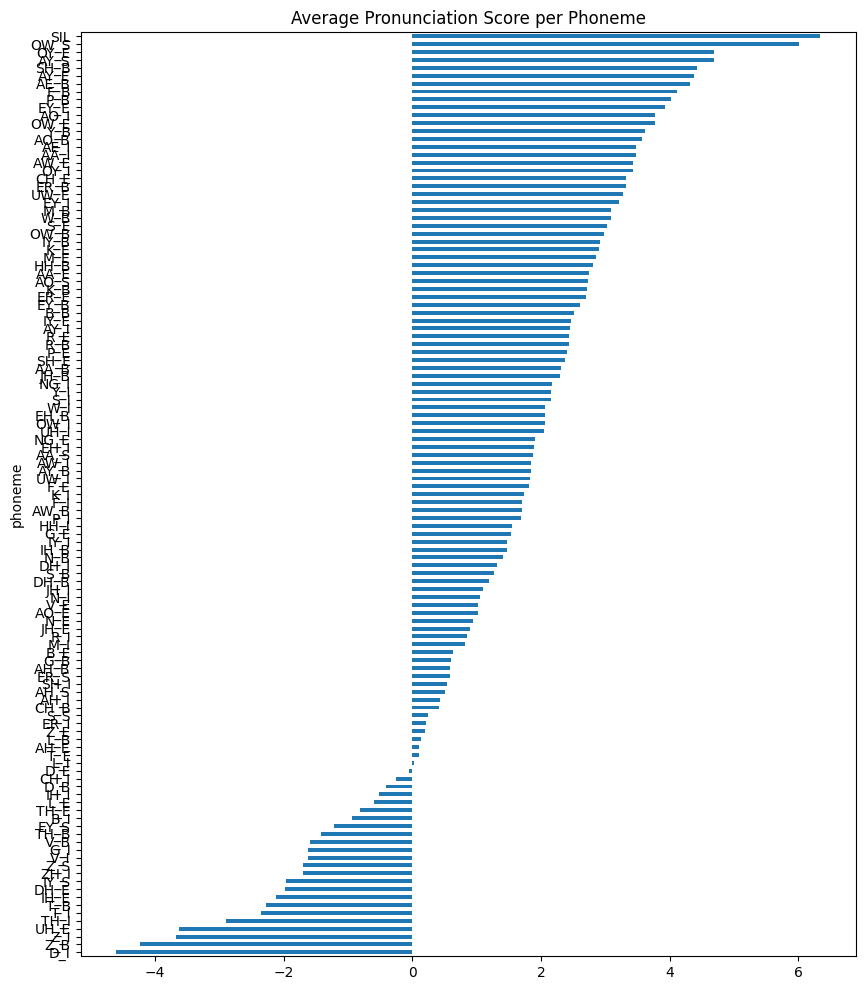

In [ ]:
import matplotlib.pyplot as plt

phoneme_mean = (
    df.groupby("phoneme")["score"]
      .mean()
      .sort_values()
)
print(phoneme_mean.head(10))

plt.figure(figsize=(10,12))
phoneme_mean.plot(kind="barh")
plt.title("Average Pronunciation Score per Phoneme")
plt.show()

In [ ]:
phoneme_stats = df.groupby("phoneme")["score"].mean()

In [ ]:
import pandas as pd

phoneme_mean = df.groupby("phoneme")["score"].mean().reset_index()

phoneme_mean["cluster"] = pd.cut(
    phoneme_mean["score"],
    bins=[-10, 1, 3, 10],
    labels=["Low", "Medium", "High"]
)

print(phoneme_mean.sort_values("score"))

    phoneme     score cluster
32      D_I -4.610290     Low
113     Z_B -4.239489     Low
115     Z_I -3.677778     Low
101    UH_E -3.627941     Low
97     TH_I -2.896433     Low
..      ...       ...     ...
87     SH_B  4.417293    High
20     AY_S  4.682598    High
79     OY_E  4.688823    High
78     OW_S  6.004085    High
90      SIL  6.339483    High

[117 rows x 3 columns]


In [ ]:
phoneme_features = (
    df.groupby("phoneme")["score"]
      .agg(["mean","std"])
      .reset_index()
)

In [ ]:
from sklearn.cluster import KMeans

# Create a copy to avoid SettingWithCopyWarning
phoneme_features_cleaned = phoneme_features.copy().dropna()

X = phoneme_features_cleaned[["mean","std"]]

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init='auto'
)

phoneme_features_cleaned["cluster"] = kmeans.fit_predict(X)
# To merge the cluster information back to the original phoneme_features, if needed
# phoneme_features = phoneme_features.merge(phoneme_features_cleaned[['phoneme', 'cluster']], on='phoneme', how='left')

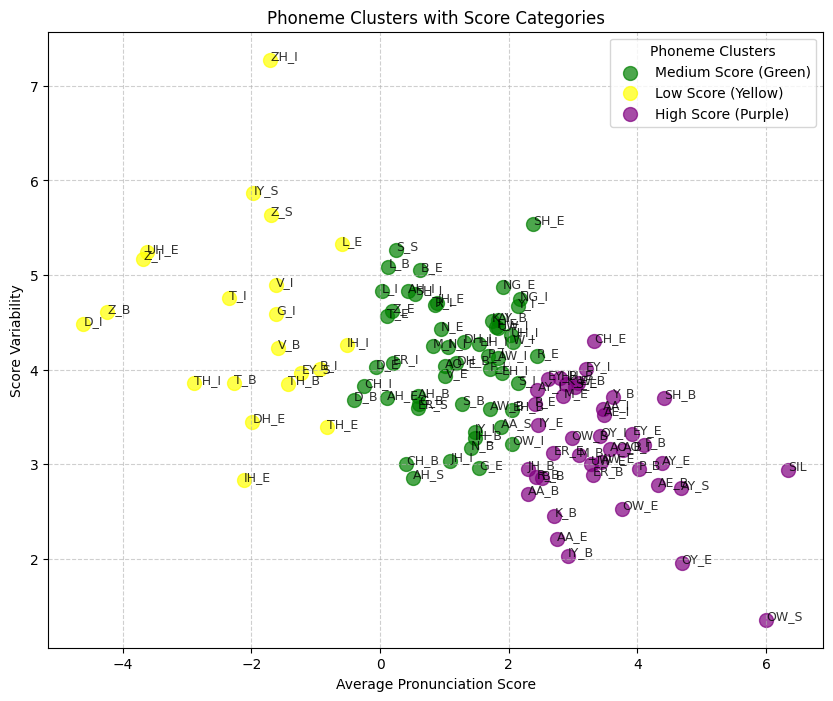

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

# Define colors and labels for each cluster based on user's request
cluster_colors = {
    0: 'green',
    1: 'yellow',
    2: 'purple'
}

cluster_labels = {
    0: 'Medium Score (Green)',
    1: 'Low Score (Yellow)',
    2: 'High Score (Purple)'
}

# Plot each cluster separately to create distinct legend entries
for cluster_id in sorted(phoneme_features_cleaned['cluster'].unique()):
    subset = phoneme_features_cleaned[phoneme_features_cleaned['cluster'] == cluster_id]
    plt.scatter(
        subset["mean"],
        subset["std"],
        color=cluster_colors[cluster_id],
        s=100,
        alpha=0.7,
        label=cluster_labels[cluster_id]
    )

for _, row in phoneme_features_cleaned.iterrows():
    plt.annotate(
        row["phoneme"],
        (row["mean"], row["std"]),
        fontsize=9,
        alpha=0.8
    )

plt.xlabel("Average Pronunciation Score")
plt.ylabel("Score Variability")
plt.title("Phoneme Clusters with Score Categories")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Phoneme Clusters") # Add legend
plt.show()

In [ ]:
phoneme_features_cleaned['base_phoneme'] = phoneme_features_cleaned['phoneme'].apply(lambda x: x.split('_')[0])
phoneme_features_cleaned['type'] = phoneme_features_cleaned['base_phoneme'].apply(lambda x: 'vowel' if x in vowels else 'consonant')

vowel_features = phoneme_features_cleaned[phoneme_features_cleaned['type'] == 'vowel']
consonant_features = phoneme_features_cleaned[phoneme_features_cleaned['type'] == 'consonant']

display(phoneme_features_cleaned.head())

,phoneme,mean,std,cluster,base_phoneme,type
0,AA_B,2.304857,2.685575,2,AA,vowel
1,AA_E,2.746743,2.207558,2,AA,vowel
2,AA_I,3.471250,3.585981,2,AA,vowel
3,AA_S,1.874136,3.395773,0,AA,vowel
4,AE_B,4.321722,2.778065,2,AE,vowel


Now that we have categorized each phoneme, let's visualize the clusters for vowels and consonants separately.

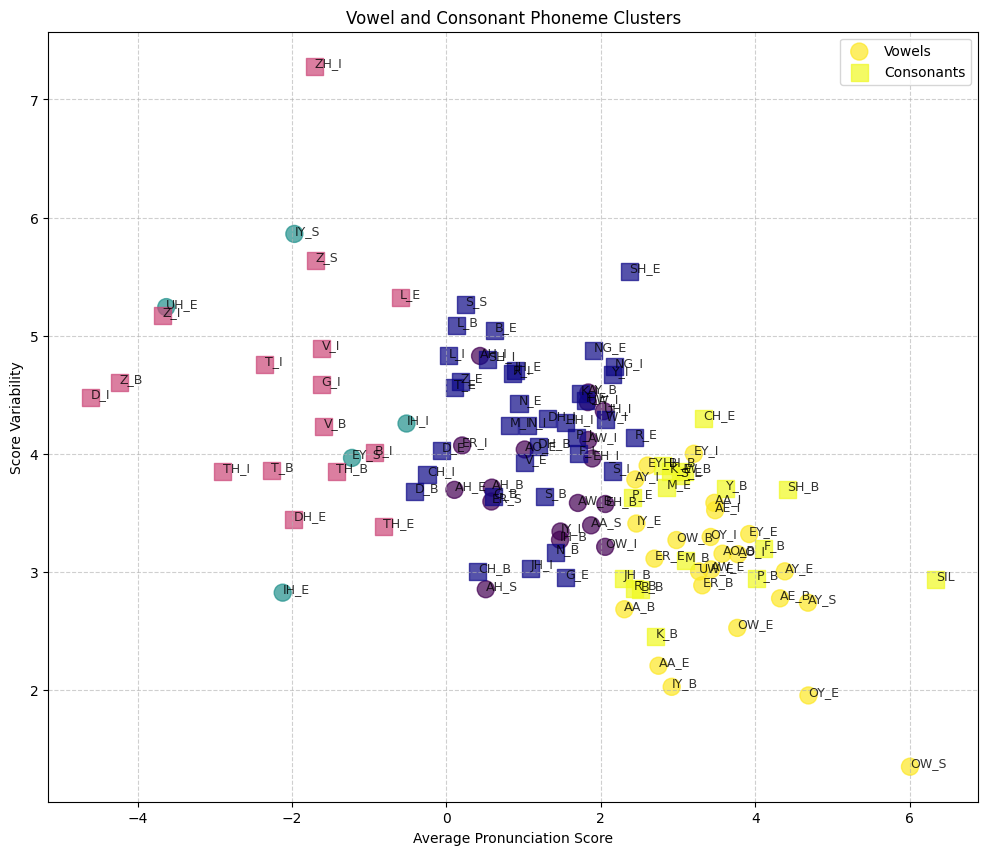

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))

# Plot for Vowels
plt.scatter(
    vowel_features["mean"],
    vowel_features["std"],
    c=vowel_features["cluster"],
    s=150,
    alpha=0.7,
    cmap='viridis',
    marker='o', # Use circles for vowels
    label='Vowels'
)

for _, row in vowel_features.iterrows():
    plt.annotate(
        row["phoneme"],
        (row["mean"], row["std"]),
        fontsize=9,
        alpha=0.8
    )

# Plot for Consonants
plt.scatter(
    consonant_features["mean"],
    consonant_features["std"],
    c=consonant_features["cluster"],
    s=150,
    alpha=0.7,
    cmap='plasma',
    marker='s', # Use squares for consonants
    label='Consonants'
)

for _, row in consonant_features.iterrows():
    plt.annotate(
        row["phoneme"],
        (row["mean"], row["std"]),
        fontsize=9,
        alpha=0.8
    )

plt.xlabel("Average Pronunciation Score")
plt.ylabel("Score Variability")
plt.title("Vowel and Consonant Phoneme Clusters")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend() # Add a legend to distinguish vowels and consonants
plt.show()

In [ ]:
import os
import pandas as pd
import numpy as np

folder = "/content/speechocean/train/learners"

all_words = []
all_sentences = []

for file in os.listdir(folder):

    if not file.endswith(".txt"):
        continue

    filepath = os.path.join(folder, file)

    current_word_phonemes = []
    current_word_scores = []

    sentence_word_scores = []
    word_count_in_sentence = 0  # Initialize word counter for each file

    with open(filepath, "r") as f:

        for line in f:

            parts = line.strip().split()

            if len(parts) != 2:
                continue

            phoneme = parts[0]
            score = float(parts[1])

            # Ignore silence
            if phoneme == "SIL":
                continue

            # Beginning of word
            if phoneme.endswith("_B"):

                current_word_phonemes = [phoneme]
                current_word_scores = [score]

            # Intermediate phoneme
            elif phoneme.endswith("_I"):

                current_word_phonemes.append(phoneme)
                current_word_scores.append(score)

            # End phoneme
            elif phoneme.endswith("_E"):

                current_word_phonemes.append(phoneme)
                current_word_scores.append(score)

                word_score = np.mean(current_word_scores)

                sentence_word_scores.append(word_score)

                all_words.append({
                    "file": file,
                    "word_id": word_count_in_sentence, # Add word_id here
                    "word_phonemes": " ".join(current_word_phonemes),
                    "num_phonemes": len(current_word_scores),
                    "word_gop": word_score
                })
                word_count_in_sentence += 1 # Increment for the next word

                current_word_phonemes = []
                current_word_scores = []

    # Sentence-level score
    if len(sentence_word_scores) > 0:

        sentence_score = np.mean(sentence_word_scores)

        all_sentences.append({
            "file": file,
            "num_words": len(sentence_word_scores),
            "sentence_gop": sentence_score
        })

word_df = pd.DataFrame(all_words)
sentence_df = pd.DataFrame(all_sentences)

print("Total Words:", len(word_df))
print("Total Sentences:", len(sentence_df))

display(word_df.head())

Total Words: 14953
Total Sentences: 2500


,file,word_id,word_phonemes,num_phonemes,word_gop
0,000530163.txt,0,W_B EH_I R_E,3,3.266073
1,000530163.txt,1,D_B IH_I D_E,3,-3.224924
2,000530163.txt,2,DH_B AE_I T_E,3,-0.126121
3,000530163.txt,3,K_B AH_I M_E,3,4.704545
4,000530163.txt,4,F_B R_I AH_I M_E,4,0.635107


In [ ]:
import os
import pandas as pd

# Assuming 'folder' variable is already defined from previous cells
# folder = "/content/speechocean/train/learners"

all_gop_phonemes = []

for file in os.listdir(folder):
    if not file.endswith(".txt"):
        continue

    filepath = os.path.join(folder, file)
    phoneme_id_counter = 0 # Reset for each file

    with open(filepath, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                phoneme = parts[0]
                gop_score = float(parts[1])

                all_gop_phonemes.append({
                    "file": file,
                    "phoneme": phoneme,
                    "phoneme_id": phoneme_id_counter,
                    "gop_score": gop_score
                })
                phoneme_id_counter += 1

phoneme_df = pd.DataFrame(all_gop_phonemes)
print("Total Phonemes:", len(phoneme_df))
display(phoneme_df.head())

Total Phonemes: 55605


,file,phoneme,phoneme_id,gop_score
0,000530163.txt,SIL,0,8.091264
1,000530163.txt,W_B,1,4.118575
2,000530163.txt,EH_I,2,3.524633
3,000530163.txt,R_E,3,2.155012
4,000530163.txt,SIL,4,2.241138


In [ ]:
import json                          #SENTENCE-LEVEL CORRELATION
import pandas as pd
import numpy as np

with open("/content/scores.json") as f:
    data = json.load(f)

sentence_scores = []

for utt_id, info in data.items():

    total = info["total"]

    if isinstance(total, list):
        total = np.mean(total)

    sentence_scores.append({
        "file": utt_id + ".txt",
        "human_sentence_score": total
    })

human_sentence_df = pd.DataFrame(sentence_scores)

human_sentence_df.head()

,file,human_sentence_score
0,000010011.txt,8
1,000010035.txt,8
2,000010053.txt,9
3,000010063.txt,9
4,000010069.txt,9


In [ ]:
from scipy.stats import pearsonr,spearmanr   #SENTENCE-LEVEL CORRELATION

merged_sentence = pd.merge(
    sentence_df,
    human_sentence_df,
    on="file"
)

pearson,_ = pearsonr(
    merged_sentence["sentence_gop"],
    merged_sentence["human_sentence_score"]
)

spearman,_ = spearmanr(
    merged_sentence["sentence_gop"],
    merged_sentence["human_sentence_score"]
)

print("Sentence Pearson :",pearson)
print("Sentence Spearman:",spearman)

Sentence Pearson : 0.6249152667086216
Sentence Spearman: 0.5442308173505856


In [ ]:
import json                                   # WORD-LEVEL CORRELATION
import pandas as pd
import numpy as np

with open('/content/scores.json') as f:
    data = json.load(f)

human_word_scores = []

for utt_id, info in data.items():

    for idx, word in enumerate(info["words"]):

        score = word["total"]

        if isinstance(score, list):
            score = np.mean(score)

        human_word_scores.append({
            "file": utt_id + ".txt",
            "word_id": idx,
            "human_word_score": score
        })

human_word_df = pd.DataFrame(human_word_scores)

In [ ]:
from scipy.stats import pearsonr, spearmanr      # WORD-LEVEL CORRELATION

merged_word = pd.merge(
    word_df,
    human_word_df,
    on=["file","word_id"]
)

pearson_word, _ = pearsonr(
    merged_word["word_gop"],
    merged_word["human_word_score"]
)

spearman_word, _ = spearmanr(
    merged_word["word_gop"],
    merged_word["human_word_score"]
)

print("Word Pearson :", pearson_word)
print("Word Spearman:", spearman_word)

Word Pearson : 0.3772072447804285
Word Spearman: 0.3232281513077527


In [ ]:
human_phone_scores = []                            # PHONEME_LEVEL CORRELATION

for utt_id, info in data.items():

    phone_id = 0

    for word in info["words"]:

        phones = word["phones"]
        scores = word["phones-accuracy"]

        for p, s in zip(phones, scores):

            human_phone_scores.append({
                "file": utt_id + ".txt",
                "phoneme_id": phone_id,
                "human_phone_score": s
            })

            phone_id += 1

human_phoneme_df = pd.DataFrame(human_phone_scores)

In [ ]:
merged_phone = pd.merge(                 # PHONEME_LEVEL CORRELATION
    phoneme_df,
    human_phoneme_df,
    on=["file","phoneme_id"]
)

pearson_phone, _ = pearsonr(
    merged_phone["gop_score"],
    merged_phone["human_phone_score"]
)

spearman_phone, _ = spearmanr(
    merged_phone["gop_score"],
    merged_phone["human_phone_score"]
)

print("Phoneme Pearson :", pearson_phone)
print("Phoneme Spearman:", spearman_phone)

Phoneme Pearson : 0.15894977839189445
Phoneme Spearman: 0.13148563863787988


In [ ]:
vowels = [
    'AA','AE','AH','AO','AW','AY',
    'EH','ER','EY',
    'IH','IY',
    'OW','OY',
    'UH','UW'
]

In [ ]:
import re

merged_phone["base_phoneme"] = merged_phone["phoneme"].apply(
    # Remove digits and suffixes like '_B', '_I', '_E'
    lambda x: re.sub(r"(_[BIE]|\\d)", "", x)
)
vowel_df = merged_phone[
    merged_phone["base_phoneme"].isin(vowels)
]

consonant_df = merged_phone[
    ~merged_phone["base_phoneme"].isin(vowels)
]

In [ ]:
#Vowel Pearson Correlation
from scipy.stats import pearsonr

vowel_corr, _ = pearsonr(
    vowel_df["gop_score"],
    vowel_df["human_phone_score"]
)

print("Vowel Pearson Correlation =", round(vowel_corr,3))

Vowel Pearson Correlation = 0.247


In [ ]:
#Consonant Pearson Correlation
consonant_corr, _ = pearsonr(
    consonant_df["gop_score"],
    consonant_df["human_phone_score"]
)

print("Consonant Pearson Correlation =", round(consonant_corr,3))

Consonant Pearson Correlation = 0.123
